# Chapter 7: Working with Text Data

We already discussed continuous and categorical features, but a third type of feature is text.

In [1]:
# create an environment where we can import all the needed modules
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

In [ ]:
!tree -L 2 ../introduction_to_ml_with_python/data/aclImdb

../introduction_to_ml_with_python/data/aclImdb
├── README
├── imdb.vocab
├── imdbEr.txt
├── test
│   ├── labeledBow.feat
│   ├── neg
│   ├── pos
│   ├── urls_neg.txt
│   └── urls_pos.txt
└── train
    ├── labeledBow.feat
    ├── neg
    ├── pos
    ├── unsup
    ├── unsupBow.feat
    ├── urls_neg.txt
    ├── urls_pos.txt
    └── urls_unsup.txt

8 directories, 11 files


In [ ]:
# load the data
from sklearn.datasets import load_files

review_train       = load_files("../introduction_to_ml_with_python/data/aclImdb/train/")
text_train, ytrain = review_train.data, review_train.target
print(type(text_train), len(text_train), text_train[1])

<class 'list'> 75000 b"Amount of disappointment I am getting these days seeing movies like Partner, Jhoom Barabar and now, Heyy Babyy is gonna end my habit of seeing first day shows.<br /><br />The movie is an utter disappointment because it had the potential to become a laugh riot only if the d\xc3\xa9butant director, Sajid Khan hadn't tried too many things. Only saving grace in the movie were the last thirty minutes, which were seriously funny elsewhere the movie fails miserably. First half was desperately been tried to look funny but wasn't. Next 45 minutes were emotional and looked totally artificial and illogical.<br /><br />OK, when you are out for a movie like this you don't expect much logic but all the flaws tend to appear when you don't enjoy the movie and thats the case with Heyy Babyy. Acting is good but thats not enough to keep one interested.<br /><br />For the positives, you can take hot actresses, last 30 minutes, some comic scenes, good acting by the lead cast and the 

In [7]:
# do some formatting. Not sure if this applies now
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

In [8]:
# just looking into the data more
import numpy as np
print("Samples per class", np.bincount(ytrain))

Samples per class [12500 12500 50000]


In [19]:
# load test data

review_test      = load_files("../introduction_to_ml_with_python/data/aclImdb/test/")
text_test, ytest = review_test.data, review_test.target
text_test        = [doc.replace(b"<br />", b" ") for doc in text_test]
print(len(text_test), np.bincount(ytest))



25000 [12500 12500]


## Representing Text Data as a Bag of Words

One of the most simple but effective and commonly used ways to represent text for machine learning is using the **bag-of-words** representation. By discarding most of the structure of the input text (e.g., chapters, paragraphs, sentences, & formatting), and only counting *how often each word appears in each text* in the corpus, we create an image of representing text as a bag.

This approach consist of three steps:
1. *Tokenization*. Split each document into words that appear in it (called *tokens*)
2. *Vocabulary building*. Collect a vocabulary of all words that appear in any of the documents, and number them (say, in alphabetical order)
3. *Encoding*. For each document, count how often each of the words in the vocabulary appear in this document.

In [12]:
# let's ue a transformer to an implementation ourselves
from sklearn.feature_extraction.text import CountVectorizer

bards_words = ["The fool doth think he is wise,", "but the wise man knows himself to be a fool"]
vect        = CountVectorizer()
vect.fit(bards_words)

print(len(vect.vocabulary_))
print(vect.vocabulary_)

# create the bag
bag_of_words = vect.transform(bards_words)
print(repr(bag_of_words))

13
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}
<2x13 sparse matrix of type '<class 'numpy.int64'>'
	with 16 stored elements in Compressed Sparse Row format>


In [ ]:
# 
# it's a sparse matrix, so to visualize, we need to
# convert it to a dense matrix
#
print(bag_of_words.toarray()) # neither string contains a word twice, so it's either 0 or 1

[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


In [14]:
# apply it to our data now
vect   = CountVectorizer().fit(text_train)
xtrain = vect.transform(text_train)
print(repr(xtrain))

<75000x124255 sparse matrix of type '<class 'numpy.int64'>'
	with 10315542 stored elements in Compressed Sparse Row format>


In [15]:
# get each feature
feature_names = vect.get_feature_names()
print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 124255
First 20 features:
['00', '000', '0000', '0000000000000000000000000000000001', '0000000000001', '000000001', '000000003', '00000001', '000001745', '00001', '0001', '00015', '0002', '0007', '00083', '000ft', '000s', '000th', '001', '002']
Features 20010 to 20030:
['cheapen', 'cheapened', 'cheapening', 'cheapens', 'cheaper', 'cheapest', 'cheapie', 'cheapies', 'cheapjack', 'cheaply', 'cheapness', 'cheapo', 'cheapozoid', 'cheapquels', 'cheapskate', 'cheapskates', 'cheapy', 'chearator', 'cheat', 'cheata']
Every 2000th feature:
['00', '_require_', 'aideed', 'announcement', 'asteroid', 'banquière', 'besieged', 'bollwood', 'btvs', 'carboni', 'chcialbym', 'clotheth', 'consecration', 'cringeful', 'deadness', 'devagan', 'doberman', 'duvall', 'endocrine', 'existent', 'fetiches', 'formatted', 'garard', 'godlie', 'gumshoe', 'heathen', 'honoré', 'immatured', 'interested', 'jewelry', 'kerchner', 'köln', 'leydon', 'lulu', 'mardjono', 'meistersinger', 'misspells', 'mumblecore'

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
# let's try creating a model for this before moving further
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(), xtrain, ytrain, cv = 5)
print(np.mean(scores)) # 0.67..

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

0.6720266666666668


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# let's find a parameter to better tune the model
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid       = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(xtrain, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # 0.89, so only slightly better
print("Best parameters: ", grid.best_params_)

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Best cross-validation score: 0.68
Best parameters:  {'C': 0.01}


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# now apply it on the test
xtest = vect.transform(text_test)
print(grid.score(xtest, ytest)) # this is poor..

0.10864


We can improve this by removing some of the noise. For example, a token that only appears in only a single document is unlikely to appear in the test set and is therefore not helpful.

In [21]:
vect   = CountVectorizer(min_df=5).fit(text_train) # token must show up in at least 5 documents
xtrain = vect.transform(text_train)
print(repr(xtrain))

<75000x44532 sparse matrix of type '<class 'numpy.int64'>'
	with 10191240 stored elements in Compressed Sparse Row format>


In [22]:
feature_names = vect.get_feature_names()
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00', '000', '001', '007', '00am', '00pm', '00s', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '100', '1000', '1001', '100k', '100th', '100x', '101', '101st', '102', '103', '104', '105', '106', '107', '108', '109', '10am', '10pm', '10s', '10th', '10x', '11', '110', '1100', '110th', '111', '112', '1138', '115', '116', '117', '11pm', '11th']
Features 20010 to 20030:
['inert', 'inertia', 'inescapable', 'inescapably', 'inevitability', 'inevitable', 'inevitably', 'inexcusable', 'inexcusably', 'inexhaustible', 'inexistent', 'inexorable', 'inexorably', 'inexpensive', 'inexperience', 'inexperienced', 'inexplicable', 'inexplicably', 'inexpressive', 'inextricably']
Every 700th feature:
['00', 'accountability', 'alienate', 'appetite', 'austen', 'battleground', 'bitten', 'bowel', 'burton', 'cat', 'choreographing', 'collide', 'constipation', 'creatively', 'dashes', 'descended', 'dishing', 'dramatist', 'ejaculation', 'epitomize', 'extinguished', 'figment', 'forgot'

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [23]:
# how did the model do
grid = GridSearchCV(LogisticRegression(), param_grid=param_grid, cv=5)
grid.fit(xtrain, ytrain)
print(grid.best_score_)

# the score is the same, so our model isn't more accurate,
# but we removed uninformative features, making the model
# process the data faster

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

0.6799999999999999


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Another way to denoise text data is to get rid of uninformative words that are *too frequent* to be imformative. There are two methods to do so. Using a language-specific list of stopwords, or discarding words that appear too frequently.

In [24]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(len(ENGLISH_STOP_WORDS), list(ENGLISH_STOP_WORDS)[::10])

318 ['nor', 'where', 'eight', 'because', 'indeed', 'in', 'done', 'least', 'between', 'therein', 'besides', 'wherever', 'wherein', 'beside', 'her', 'himself', 'sixty', 'whole', 'describe', 'un', 'been', 'though', 'into', 'below', 'five', 'by', 'everything', 'off', 'hence', 'nine', 'became', 'somewhere']


In [ ]:
# the function has these words built-in
vect   = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
xtrain = vect.transform(text_train)
print(repr(xtrain))

#
# max_df can be used to remove words based on a threshold
#

<75000x44223 sparse matrix of type '<class 'numpy.int64'>'
	with 6577418 stored elements in Compressed Sparse Row format>


In [ ]:
# how does it perform now
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(xtrain, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # improve to 0.71

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Best cross-validation score: 0.71


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Rescaling the Data with tf-idf

Instead of dropping features that are deemed unimportant, another approach is to rescale features by how informative we expect them to be. One of the most common ways to do this is using the **term frequency-inverse document frequency (tf-idf)** method. The intuition of this method is to give high weight to any term that appears often in a particular document, but not in many documents in the corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe       = make_pipeline(TfidfVectorizer(min_df=5, norm=None), LogisticRegression())
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}
grid       = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # 0.72, so some improvement


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Best cross-validation score: 0.72


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
#
# find which words the model found to be important (i.e., informative)
#

vectorizer      = grid.best_estimator_.named_steps["tfidfvectorizer"]
xtrain          = vectorizer.transform(text_train)
max_value       = xtrain.max(axis = 0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
feature_names   = np.array(vectorizer.get_feature_names())

print("Features with lowest tfidf:\n{}".format(feature_names[sorted_by_tfidf[:20]]))
print("Features with highest tfidf: \n{}".format(feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['remained' 'acclaimed' 'combines' 'rapidly' 'uniformly' 'diverse'
 'avoiding' 'fills' 'feeble' 'admired' 'wherever' 'admission' 'abound'
 'starters' 'assure' 'pivotal' 'comprehend' 'deliciously' 'strung'
 'inadvertently']
Features with highest tfidf: 
['nukie' 'reno' 'dominick' 'taz' 'ling' 'rob' 'victoria' 'turtles'
 'khouri' 'lorenzo' 'id' 'zizek' 'elwood' 'nikita' 'rishi' 'timon'
 'titanic' 'zohan' 'pammy' 'godzilla']


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


We can also find the words that have low inverse document frequency, that is, those that appear frequently and are therefore deemed less important.

In [29]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'one' 'be' 'have' 'are' 'film' 'you' 'all'
 'at' 'an' 'by' 'from' 'so' 'like' 'who' 'there' 'they' 'his' 'if' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'can' 'good' 'when' 'more'
 'up' 'time' 'very' 'even' 'only' 'no' 'see' 'would' 'my' 'story' 'really'
 'which' 'well' 'had' 'me' 'than' 'their' 'much' 'were' 'get' 'other' 'do'
 'been' 'most' 'also' 'into' 'don' 'her' 'first' 'great' 'how' 'made'
 'people' 'will' 'make' 'because' 'way' 'could' 'bad' 'we' 'after' 'them'
 'too' 'any' 'then' 'movies' 'watch' 'she' 'think' 'seen' 'acting' 'its'
 'characters']


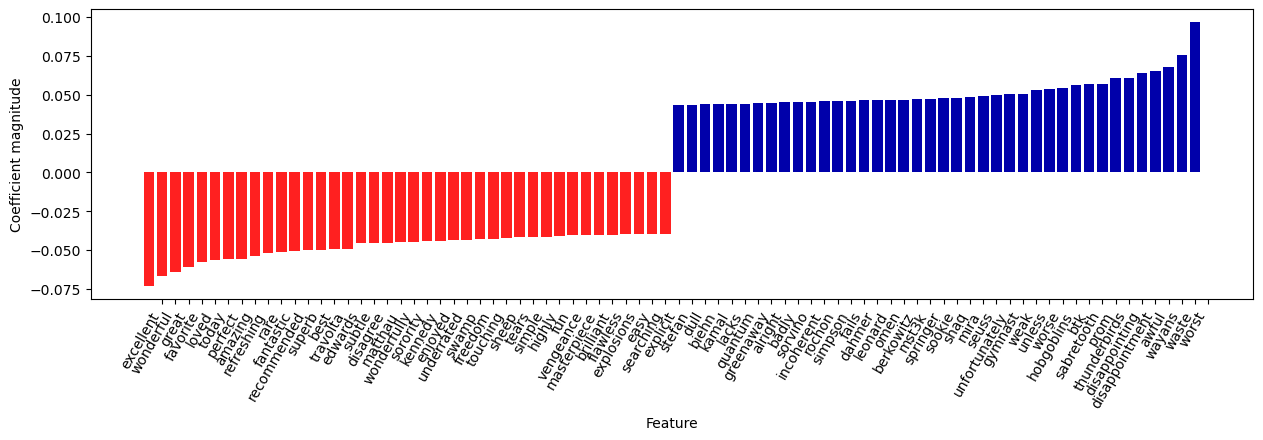

In [36]:
# visualize the coeffients estimate from our model
mglearn.tools.visualize_coefficients(grid.best_estimator_.named_steps["logisticregression"].coef_[0], feature_names, n_top_features=40)

In [32]:
grid.best_estimator_.named_steps["logisticregression"].coef_

array([[ 6.71041246e-03,  3.68973840e-03,  8.33983877e-03, ...,
         2.45146702e-03, -2.00962243e-03,  4.68596044e-03],
       [-1.01602502e-02, -1.30719560e-02, -4.07226198e-03, ...,
         7.09132092e-07, -1.95146637e-03, -2.29595910e-03],
       [ 3.44983773e-03,  9.38221762e-03, -4.26757679e-03, ...,
        -2.45217615e-03,  3.96108880e-03, -2.39000134e-03]])

One of the main disadvantages of using a bag-of-words representation is that the word order is completely discard. Therefore, the two strings *"it's bad, not good at all"* and *"it's good, not bad at all"* have exactly the same representation even though the meanings are inverted.

To capture context, we can capture the counts of pairs or triplets of tokens that appear next to each other. Pairs of tokens are known as *bigrams*, triplets of tokens are known as *trigrams*, and more generally sequences of tokens are known as *n-grams*.

In [37]:
print(bards_words)

['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


In [39]:
# we can change the pair size using a tuple(min length, max length)
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

13
['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']
14
['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


For most applications, the minimum number of tokens should be one, as single words often capture a lot of meaning. Adding bigrams helps in most cases. But the higher the pair size, the more features the model will have to deal with and higher likelihood of overfitting.

In [41]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

39
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


In [ ]:
# use grid search to find the best n-gram range

pipe       = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression())
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100], 
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_)) # 0.71 accurate, NOTE: took ~47 minutes to run

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Best cross-validation score: 0.71
Best parameters:
{'logisticregression__C': 10, 'tfidfvectorizer__ngram_range': (1, 2)}


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


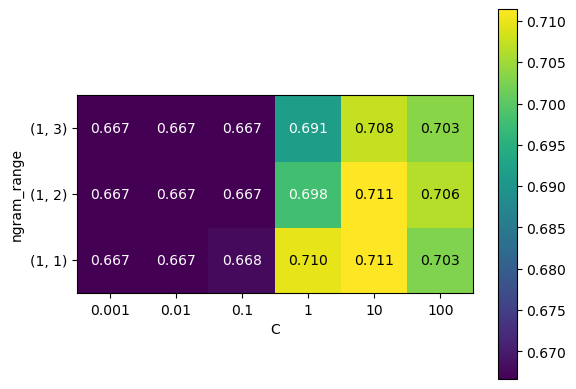

In [43]:
# visualize our parameter space
import matplotlib.pyplot as plt

scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T

# visualize heat map
heatmap = mglearn.tools.heatmap(scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f", xticklabels=param_grid['logisticregression__C'], yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

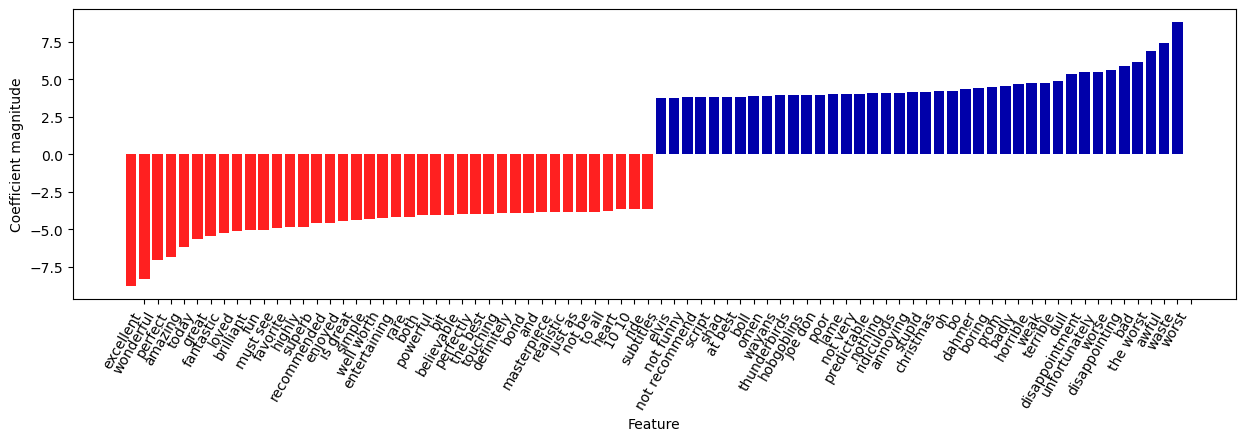

In [45]:
# now look at the coefficients
vect          = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names())
coef          = grid.best_estimator_.named_steps['logisticregression'].coef_[0]
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

ValueError: shape mismatch: objects cannot be broadcast to a single shape

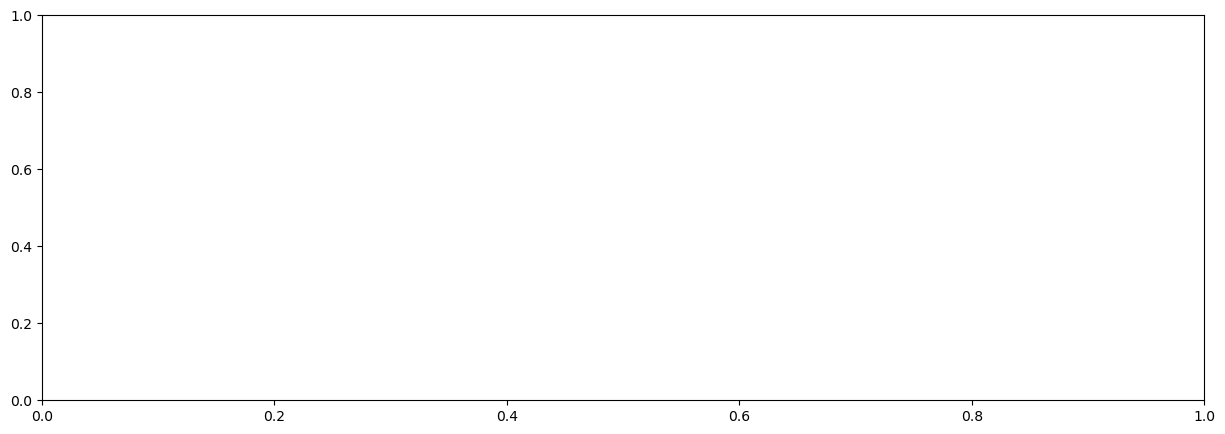

In [46]:
# coefficients for tri-grams
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
mglearn.tools.visualize_coefficients(coef.ravel()[mask], feature_names[mask], n_top_features=40)

## Advanced Tokenization, Stemming, and Lemmatization